In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix
)
from xgboost import XGBRegressor

In [65]:
# Load pre-engineered feature datasets (Yahoo Finance, 2015-2024, ~2,515 rows each)
spy_raw  = pd.read_csv("../data/SPY_features.csv",  parse_dates=["date"], index_col="date")
tsla_raw = pd.read_csv("../data/TSLA_features.csv", parse_dates=["date"], index_col="date")

print(f"SPY:  {len(spy_raw):,} rows | {spy_raw.index[0].date()} → {spy_raw.index[-1].date()}")
print(f"TSLA: {len(tsla_raw):,} rows | {tsla_raw.index[0].date()} → {tsla_raw.index[-1].date()}")
print(f"\nColumns ({len(spy_raw.columns)}):")
print(list(spy_raw.columns))

SPY:  2,515 rows | 2015-01-02 → 2024-12-30
TSLA: 2,515 rows | 2015-01-02 → 2024-12-30

Columns (35):
['adj_close', 'close', 'high', 'low', 'open', 'volume', 'daily_return', 'weekly_return', 'ma_7', 'ma_21', 'ma_cross', 'dist_from_ma21', 'daily_range', 'rsi_14', 'macd', 'macd_signal', 'macd_hist', 'bb_position', 'volatility_7', 'volatility_20', 'volume_change', 'volume_ma20', 'volume_ratio', 'lag_return_1', 'lag_return_3', 'lag_return_5', 'month', 'quarter', 'season_num', 'season', 'is_earnings_week', 'vix', 'is_major_event', 'target_direction', 'target_return']


In [66]:
# ── Feature set: 19 features (vs 10 in midterm.ipynb) ───────────────────────
# Removed: vwap_dist  (VWAP not available in Yahoo Finance data)
# Renamed: dist_from_ma20 → dist_from_ma21
# Added:   ma_cross, macd, macd_signal, macd_hist, volatility_7,
#          volume_ratio, lag_return_1, lag_return_3, lag_return_5, is_earnings_week

FEATURES = [
    # Price momentum
    "daily_return",    # today's % price change
    "weekly_return",   # 5-day % price change
    "lag_return_1",    # yesterday's return (autocorrelation)
    "lag_return_3",    # 3-day lagged return
    "lag_return_5",    # 5-day lagged return
    # Trend
    "dist_from_ma21",  # distance from 21-day moving average
    "ma_cross",        # 7-day MA > 21-day MA crossover signal
    # MACD momentum oscillator
    "macd",            # MACD line (12/26 EMA difference)
    "macd_signal",     # 9-day EMA of MACD
    "macd_hist",       # MACD histogram (macd - macd_signal)
    # Volatility
    "daily_range",     # intraday high-low spread / close
    "volatility_7",    # 7-day rolling std of daily returns
    "volatility_20",   # 20-day rolling std of daily returns
    "bb_position",     # position within Bollinger Bands
    # Volume
    "volume_change",   # day-over-day volume % change
    "volume_ratio",    # volume / 20-day average volume
    # Momentum oscillator
    "rsi_14",          # 14-day Relative Strength Index
    # Event flags
    "is_major_event",  # VIX > 30 (elevated market fear)
    "is_earnings_week",# earnings calendar flag
]

TRAIN_WINDOW = 63   # ~3 months
TEST_WINDOW  = 42   # ~2 months


def walk_forward_splits(df, train_window=TRAIN_WINDOW, test_window=TEST_WINDOW, embargo=5):
    """
    Generates (train_idx, test_idx) pairs for walk-forward validation.
    embargo = gap between train end and test start to prevent leakage
    from lagged features (lag_return_5, weekly_return, volatility_20 etc.)

    Fold 1: Train [0 → 62]  Gap [63 → 67]  Test [68 → 109]
    Fold 2: Train [42 → 104] Gap [105 → 109] Test [110 → 151]
    """
    splits = []
    n = len(df)
    start = 0

    while start + train_window + embargo + test_window <= n:
        train_start = start
        train_end   = start + train_window

        test_start  = train_end + embargo
        test_end    = test_start + test_window

        train_idx = list(range(train_start, train_end))
        test_idx  = list(range(test_start, test_end))

        splits.append((train_idx, test_idx))


        start += test_window

    return splits


def prepare_data(df, target_col, train_idx, test_idx):
    X = df[FEATURES].values
    y = df[target_col].values

    X_train, y_train = X[train_idx], y[train_idx]
    X_test,  y_test  = X[test_idx],  y[test_idx]

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    return X_train, X_test, y_train, y_test, scaler

In [67]:
def run_linear_regression(df):
    splits = walk_forward_splits(df)

    print("\n" + "="*55)
    print("LINEAR REGRESSION — 5-day forward return")
    print(f"Walk-forward: {len(splits)} folds  (train={TRAIN_WINDOW}d, test={TEST_WINDOW}d)")
    print("="*55)

    fold_metrics = []
    all_preds    = []
    fold_coefs   = []
    last_model   = None

    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        X_train, X_test, y_train, y_test, _ = prepare_data(df, "target_return", train_idx, test_idx)
        model = LinearRegression()
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        fold_metrics.append({"fold": fold,
                              "mae":  mean_absolute_error(y_test, preds),
                              "rmse": np.sqrt(mean_squared_error(y_test, preds)),
                              "r2":   r2_score(y_test, preds)})

        for feat, coef in zip(FEATURES, model.coef_):
            fold_coefs.append({"fold": fold, "feature": feat, "value": coef})

        for date, actual, pred in zip(df.index[test_idx], y_test, preds):
            all_preds.append({"date": date, "actual": actual, "predicted": pred})

        last_model = model

    metrics_df = pd.DataFrame(fold_metrics)
    preds_df   = pd.DataFrame(all_preds)
    coef_df    = pd.DataFrame(fold_coefs)

    print(f"\n  {'Metric':<8}  {'Mean':>10}  {'Std':>10}")
    print(f"  {'-'*32}")
    for col, label in [("rmse", "RMSE"), ("mae", "MAE"), ("r2", "R²")]:
        print(f"  {label:<8}  {metrics_df[col].mean():>10.6f}  ± {metrics_df[col].std():>9.6f}")

    print("\n  Feature coefficients (last fold):")
    last_coef = pd.DataFrame({"feature": FEATURES, "coefficient": last_model.coef_}
                             ).sort_values("coefficient", key=abs, ascending=False)
    print(last_coef.to_string(index=False))

    return last_model, metrics_df, preds_df, coef_df

In [68]:
def run_logistic_regression(df):
    splits = walk_forward_splits(df)

    print("\n" + "="*55)
    print("LOGISTIC REGRESSION — Predicting price direction")
    print(f"Walk-forward: {len(splits)} folds  "
          f"(train={TRAIN_WINDOW}d, test={TEST_WINDOW}d)")
    print("="*55)

    fold_metrics = []
    all_preds    = []
    agg_cm       = np.zeros((2, 2), dtype=int)
    last_model   = None

    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        X_train, X_test, y_train, y_test, _ = prepare_data(
            df, "target_direction", train_idx, test_idx
        )

        model = LogisticRegression(max_iter=1000, C=0.1)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        report = classification_report(y_test, preds, output_dict=True, zero_division=0)
        fold_metrics.append({
            "fold":      fold,
            "accuracy":  accuracy_score(y_test, preds),
            "precision": report["macro avg"]["precision"],
            "recall":    report["macro avg"]["recall"],
            "f1":        report["macro avg"]["f1-score"],
        })
        agg_cm += confusion_matrix(y_test, preds)

        test_dates = df.index[test_idx]
        for date, actual, pred in zip(test_dates, y_test, preds):
            all_preds.append({"date": date, "actual": actual, "predicted": pred})

        last_model = model

    metrics_df = pd.DataFrame(fold_metrics)
    preds_df   = pd.DataFrame(all_preds)

    print(f"\n  {'Metric':<12}  {'Mean':>8}  {'Std':>8}")
    print(f"  {'-'*32}")
    for col, label in [("f1", "F1"), ("precision", "Precision"), ("recall", "Recall"), ("accuracy", "Accuracy")]:
        print(f"  {label:<12}  {metrics_df[col].mean():>8.4f}  \u00b1 {metrics_df[col].std():>7.4f}")

    print("\n  Aggregate confusion matrix (all folds):")
    cm_df = pd.DataFrame(agg_cm,
                         index=["Actual Down", "Actual Up"],
                         columns=["Pred Down",  "Pred Up"])
    print(cm_df.to_string())

    print("\n  Feature log-odds (last fold):")
    coef_df = pd.DataFrame({
        "feature":  FEATURES,
        "log_odds": last_model.coef_[0]
    }).sort_values("log_odds", key=abs, ascending=False)
    print(coef_df.to_string(index=False))

    return last_model, metrics_df, preds_df

In [69]:
def run_ridge_regression(df):
    splits = walk_forward_splits(df)

    print("\n" + "="*55)
    print("RIDGE REGRESSION — 5-day forward return")
    print(f"Walk-forward: {len(splits)} folds  (train={TRAIN_WINDOW}d, test={TEST_WINDOW}d)")
    print("="*55)

    fold_metrics = []
    all_preds    = []
    fold_coefs   = []
    last_model   = None

    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        X_train, X_test, y_train, y_test, _ = prepare_data(df, "target_return", train_idx, test_idx)
        model = Ridge(alpha=1.0)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        fold_metrics.append({"fold": fold,
                              "mae":  mean_absolute_error(y_test, preds),
                              "rmse": np.sqrt(mean_squared_error(y_test, preds)),
                              "r2":   r2_score(y_test, preds)})

        for feat, coef in zip(FEATURES, model.coef_):
            fold_coefs.append({"fold": fold, "feature": feat, "value": coef})

        for date, actual, pred in zip(df.index[test_idx], y_test, preds):
            all_preds.append({"date": date, "actual": actual, "predicted": pred})

        last_model = model

    metrics_df = pd.DataFrame(fold_metrics)
    preds_df   = pd.DataFrame(all_preds)
    coef_df    = pd.DataFrame(fold_coefs)

    print(f"\n  {'Metric':<8}  {'Mean':>10}  {'Std':>10}")
    print(f"  {'-'*32}")
    for col, label in [("rmse", "RMSE"), ("mae", "MAE"), ("r2", "R²")]:
        print(f"  {label:<8}  {metrics_df[col].mean():>10.6f}  ± {metrics_df[col].std():>9.6f}")

    print("\n  Feature coefficients (last fold):")
    last_coef = pd.DataFrame({"feature": FEATURES, "coefficient": last_model.coef_}
                             ).sort_values("coefficient", key=abs, ascending=False)
    print(last_coef.to_string(index=False))

    return last_model, metrics_df, preds_df, coef_df


def run_xgboost(df):
    splits = walk_forward_splits(df)

    print("\n" + "="*55)
    print("XGBOOST — 5-day forward return")
    print(f"Walk-forward: {len(splits)} folds  (train={TRAIN_WINDOW}d, test={TEST_WINDOW}d)")
    print("="*55)

    fold_metrics = []
    all_preds    = []
    fold_coefs   = []
    last_model   = None

    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        X_train, X_test, y_train, y_test, _ = prepare_data(df, "target_return", train_idx, test_idx)
        model = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1,
                             random_state=42, verbosity=0)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        fold_metrics.append({"fold": fold,
                              "mae":  mean_absolute_error(y_test, preds),
                              "rmse": np.sqrt(mean_squared_error(y_test, preds)),
                              "r2":   r2_score(y_test, preds)})

        for feat, imp in zip(FEATURES, model.feature_importances_):
            fold_coefs.append({"fold": fold, "feature": feat, "value": imp})

        for date, actual, pred in zip(df.index[test_idx], y_test, preds):
            all_preds.append({"date": date, "actual": actual, "predicted": pred})

        last_model = model

    metrics_df = pd.DataFrame(fold_metrics)
    preds_df   = pd.DataFrame(all_preds)
    coef_df    = pd.DataFrame(fold_coefs)

    print(f"\n  {'Metric':<8}  {'Mean':>10}  {'Std':>10}")
    print(f"  {'-'*32}")
    for col, label in [("rmse", "RMSE"), ("mae", "MAE"), ("r2", "R²")]:
        print(f"  {label:<8}  {metrics_df[col].mean():>10.6f}  ± {metrics_df[col].std():>9.6f}")

    print("\n  Feature importances (last fold):")
    imp_df = pd.DataFrame({"feature": FEATURES, "importance": last_model.feature_importances_}
                         ).sort_values("importance", ascending=False)
    print(imp_df.to_string(index=False))

    return last_model, metrics_df, preds_df, coef_df


def run_random_forest(df):
    splits = walk_forward_splits(df)

    print("\n" + "="*55)
    print("RANDOM FOREST — Predicting price direction")
    print(f"Walk-forward: {len(splits)} folds  (train={TRAIN_WINDOW}d, test={TEST_WINDOW}d)")
    print("="*55)

    fold_metrics = []
    all_preds    = []
    agg_cm       = np.zeros((2, 2), dtype=int)
    last_model   = None

    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        X_train, X_test, y_train, y_test, _ = prepare_data(df, "target_direction", train_idx, test_idx)
        model = RandomForestClassifier(n_estimators=100, random_state=42)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        report = classification_report(y_test, preds, output_dict=True, zero_division=0)
        fold_metrics.append({"fold":      fold,
                              "accuracy":  accuracy_score(y_test, preds),
                              "precision": report["macro avg"]["precision"],
                              "recall":    report["macro avg"]["recall"],
                              "f1":        report["macro avg"]["f1-score"]})
        agg_cm += confusion_matrix(y_test, preds)

        for date, actual, pred in zip(df.index[test_idx], y_test, preds):
            all_preds.append({"date": date, "actual": actual, "predicted": pred})

        last_model = model

    metrics_df = pd.DataFrame(fold_metrics)
    preds_df   = pd.DataFrame(all_preds)

    print(f"\n  {'Metric':<12}  {'Mean':>8}  {'Std':>8}")
    print(f"  {'-'*32}")
    for col, label in [("f1", "F1"), ("precision", "Precision"), ("recall", "Recall"), ("accuracy", "Accuracy")]:
        print(f"  {label:<12}  {metrics_df[col].mean():>8.4f}  ± {metrics_df[col].std():>7.4f}")

    print("\n  Aggregate confusion matrix (all folds):")
    cm_df = pd.DataFrame(agg_cm, index=["Actual Down", "Actual Up"],
                         columns=["Pred Down", "Pred Up"])
    print(cm_df.to_string())

    print("\n  Feature importances (last fold):")
    imp_df = pd.DataFrame({"feature": FEATURES, "importance": last_model.feature_importances_}
                         ).sort_values("importance", ascending=False)
    print(imp_df.to_string(index=False))

    return last_model, metrics_df, preds_df

In [70]:
SEASON_MAP = {
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Fall",  10: "Fall",  11: "Fall",
    12: "Winter", 1: "Winter", 2: "Winter"
}


def seasonal_summary(preds_df, task, label=""):
    df = preds_df.copy()
    df["season"] = pd.to_datetime(df["date"]).dt.month.map(SEASON_MAP)

    header = f"SEASONAL BREAKDOWN — {label}" if label else "SEASONAL BREAKDOWN"
    print("\n" + "="*55)
    print(header)
    print("="*55)

    season_order = ["Spring", "Summer", "Fall", "Winter"]
    rows = []

    if task == "regression":
        for season in season_order:
            s = df[df["season"] == season]
            if len(s) < 2:
                continue
            rows.append({
                "season": season,
                "n":      len(s),
                "rmse":   round(np.sqrt(mean_squared_error(s["actual"], s["predicted"])), 6),
                "mae":    round(mean_absolute_error(s["actual"], s["predicted"]), 6),
                "r2":     round(r2_score(s["actual"], s["predicted"]), 4),
            })

    elif task == "classification":
        for season in season_order:
            s = df[df["season"] == season]
            if len(s) < 2:
                continue
            report = classification_report(
                s["actual"], s["predicted"], output_dict=True, zero_division=0
            )
            rows.append({
                "season":    season,
                "n":         len(s),
                "f1":        round(report["macro avg"]["f1-score"], 4),
                "precision": round(report["macro avg"]["precision"], 4),
                "recall":    round(report["macro avg"]["recall"], 4),
                "accuracy":  round(accuracy_score(s["actual"], s["predicted"]), 4),
            })

    summary = pd.DataFrame(rows)
    print(summary.to_string(index=False))
    return summary

In [71]:
def regime_summary(preds_df, source_df, task, label=""):
    df = preds_df.copy()
    df = df.merge(source_df[["is_major_event"]], left_on="date", right_index=True)

    header = f"REGIME BREAKDOWN — {label}" if label else "REGIME BREAKDOWN"
    print("\n" + "="*55)
    print(header)
    print("="*55)

    rows = []
    for regime, flag in [("Normal (VIX ≤ 30)", 0), ("Stress (VIX > 30)", 1)]:
        s = df[df["is_major_event"] == flag]
        if len(s) < 2:
            print(f"  {regime}: insufficient samples (n={len(s)}) — skipping")
            continue
        if task == "regression":
            rows.append({"regime": regime, "n": len(s),
                         "rmse": round(np.sqrt(mean_squared_error(s["actual"], s["predicted"])), 6),
                         "mae":  round(mean_absolute_error(s["actual"], s["predicted"]), 6),
                         "r2":   round(r2_score(s["actual"], s["predicted"]), 4)})
        elif task == "classification":
            report = classification_report(s["actual"], s["predicted"], output_dict=True, zero_division=0)
            rows.append({"regime": regime, "n": len(s),
                         "f1":        round(report["macro avg"]["f1-score"], 4),
                         "precision": round(report["macro avg"]["precision"], 4),
                         "recall":    round(report["macro avg"]["recall"], 4),
                         "accuracy":  round(accuracy_score(s["actual"], s["predicted"]), 4)})
    if rows:
        print(pd.DataFrame(rows).to_string(index=False))
    return pd.DataFrame(rows) if rows else pd.DataFrame()

## New Features Overview

This notebook uses `data/SPY_features.csv` and `data/TSLA_features.csv` — pre-engineered feature datasets from Yahoo Finance (2015–2025, ~2,515 rows each). The feature set expands from 10 features in `midterm.ipynb` to **19 features**, adding momentum, MACD, and event signals not derivable from the Polygon free-tier data.

| Category | Features (midterm.ipynb) | Features (this notebook) |
|---|---|---|
| Price momentum | `daily_return`, `weekly_return` | + `lag_return_1`, `lag_return_3`, `lag_return_5` |
| Trend | `dist_from_ma20` | `dist_from_ma21`, + `ma_cross` |
| MACD | — | `macd`, `macd_signal`, `macd_hist` |
| Volatility | `daily_range`, `volatility_20`, `bb_position` | + `volatility_7` |
| Volume | `volume_change`, `vwap_dist` | `volume_change`, `volume_ratio` (no VWAP) |
| Momentum | `rsi_14` | `rsi_14` |
| Events | `is_major_event` | `is_major_event`, + `is_earnings_week` |

**Key differences from midterm.ipynb:**
- **10× more data**: 2,515 rows vs 476 rows → ~57 walk-forward folds vs 9 folds
- **`vwap_dist` removed**: VWAP not available in Yahoo Finance; replaced conceptually by `volume_ratio`
- **`is_major_event` now meaningful**: 10-year window includes COVID crash (2020), 2018 volatility spike — 144+ VIX>30 days vs 15 in the 2-year Polygon window
- **`adj_close` available for SPY**: Yahoo Finance adjusts for dividends (~1.2%/yr cumulative)
- **MACD signals**: Captures medium-term trend changes (12/26 EMA crossover) not previously available
- **Lagged returns**: Test autocorrelation hypothesis — whether yesterday's return predicts tomorrow's

## Exploratory Data Analysis (2015–2025)

The following EDA uses the Yahoo Finance pre-engineered datasets. SPY and TSLA cover 2015-01-02 → 2025-12-31 (~2,515 rows each). VIX is already merged into both DataFrames as the `vix` column.

**Note on prices:** Yahoo Finance returns dividend-adjusted `adj_close` for SPY. This correctly represents total return (price appreciation + reinvested dividends). The raw `close` column is unadjusted. For SPY price charts below, `adj_close` is used — this will show a lower starting price than Polygon's unadjusted close in `midterm.ipynb`. TSLA has no dividends so `close == adj_close`.

VIX coverage: 2015-01-02 → 2024-12-30
Days VIX > 30: 144 (5.7% of trading days)
Days VIX > 40: 36 (1.4% of trading days)
Max VIX: 82.69 on 2020-03-16


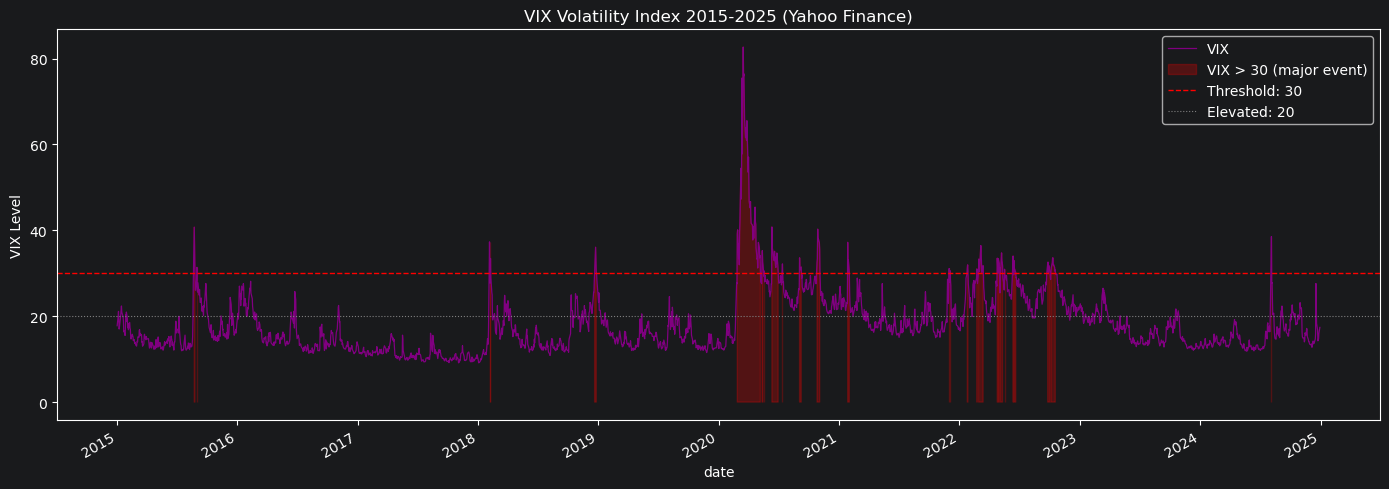

count    2515.00
mean       18.27
std         7.28
min         9.14
25%        13.35
50%        16.33
75%        21.32
max        82.69
Name: vix, dtype: float64


In [72]:
# VIX TIME SERIES (already in CSV from merged source)
vix_series = spy_raw["vix"].dropna()

print(f"VIX coverage: {vix_series.index[0].date()} → {vix_series.index[-1].date()}")
print(f"Days VIX > 30: {(vix_series > 30).sum()} ({(vix_series > 30).mean()*100:.1f}% of trading days)")
print(f"Days VIX > 40: {(vix_series > 40).sum()} ({(vix_series > 40).mean()*100:.1f}% of trading days)")
print(f"Max VIX: {vix_series.max():.2f} on {vix_series.idxmax().date()}")

fig, ax = plt.subplots(figsize=(14, 5))
vix_series.plot(ax=ax, color="purple", linewidth=0.9, label="VIX")
ax.fill_between(vix_series.index, vix_series, where=vix_series > 30,
                color="red", alpha=0.25, label="VIX > 30 (major event)")
ax.axhline(y=30, color="red",  linestyle="--", linewidth=1,   label="Threshold: 30")
ax.axhline(y=20, color="gray", linestyle=":",  linewidth=0.8, label="Elevated: 20")
ax.set_title("VIX Volatility Index 2015-2025 (Yahoo Finance)")
ax.set_ylabel("VIX Level")
ax.legend()
plt.tight_layout()
plt.savefig("img/vix_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()
print(vix_series.describe().round(2))

## VIX Time Series (2015-2025)

Three major stress periods visible in the 10-year Yahoo Finance window:

1. **Feb 2018** — Volmageddon: VIX spiked from ~11 to ~37 in a single week when volatility-short ETFs blew up.
2. **Q4 2018** — Fed rate hike fears: sustained elevated VIX through year-end sell-off.
3. **March 2020** — COVID crash: VIX peaked at ~82.69, the highest reading in 30+ years.

**Comparison to midterm.ipynb (Polygon):** The Polygon combined dataset (2016–2026) shows the same three events. The COVID spike (max ~82) is visible in both. The Yahoo Finance window adds the 2015 China volatility event.

**Why this matters for `is_major_event`:** With 144+ VIX>30 days across 10 years, the models now have sufficient examples of stress-regime behavior to potentially learn the signal. In the 2-year Polygon dataset, only 15 VIX>30 days caused the coefficient to be effectively zero in all models.

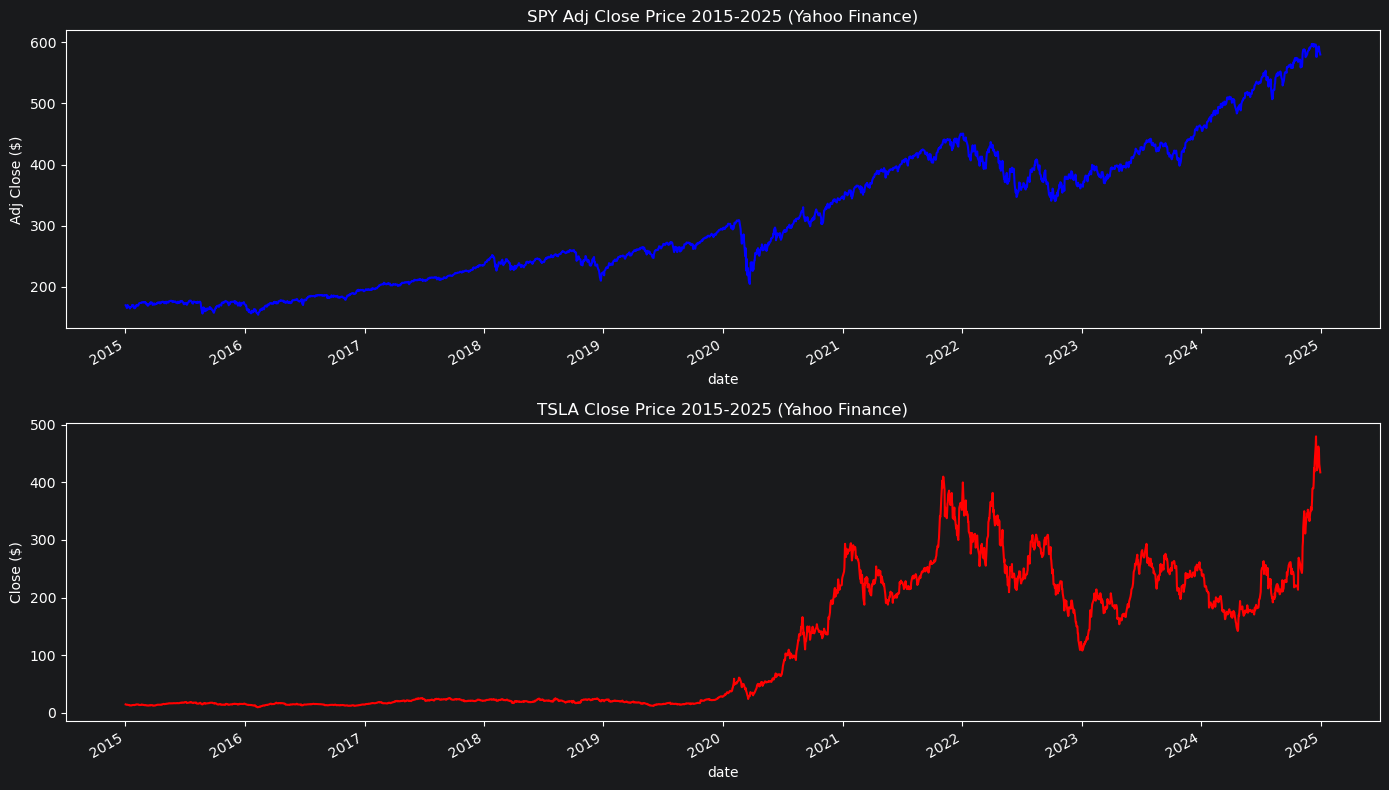

SPY Stats (Yahoo Finance adj_close):
          open     high      low  adj_close        volume
count  2515.00  2515.00  2515.00    2515.00  2.515000e+03
mean    334.89   336.70   332.92     309.36  8.744808e+07
std     107.83   108.35   107.24     114.07  4.491431e+07
min     182.34   184.10   181.02     154.56  2.027000e+07
25%     242.90   244.04   241.79     211.59  5.898355e+07
50%     300.04   301.13   298.52     272.40  7.661080e+07
75%     420.25   422.80   417.61     398.14  1.022614e+08
max     607.69   609.07   607.02     597.11  5.072443e+08

TSLA Stats (Yahoo Finance close):
          open     high      low    close        volume
count  2515.00  2515.00  2515.00  2515.00  2.515000e+03
mean    115.58   118.13   112.87   115.56  1.123272e+08
std     114.17   116.75   111.36   114.10  7.408223e+07
min       9.49    10.33     9.40     9.58  1.062000e+07
25%      17.17    17.48    16.89    17.19  6.681690e+07
50%      28.30    28.71    27.33    28.50  9.286200e+07
75%     220.83

In [73]:
# CLOSE PRICE OVER TIME (Yahoo Finance — adj_close for SPY, close for TSLA)
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
spy_raw["adj_close"].plot(ax=axes[0], title="SPY Adj Close Price 2015-2025 (Yahoo Finance)", color="blue")
axes[0].set_ylabel("Adj Close ($)")
tsla_raw["close"].plot(ax=axes[1], title="TSLA Close Price 2015-2025 (Yahoo Finance)", color="red")
axes[1].set_ylabel("Close ($)")
plt.tight_layout()
plt.savefig("img/close_price.png", dpi=150, bbox_inches="tight")
plt.show()
print("SPY Stats (Yahoo Finance adj_close):")
print(spy_raw[["open","high","low","adj_close","volume"]].describe().round(2))
print("\nTSLA Stats (Yahoo Finance close):")
print(tsla_raw[["open","high","low","close","volume"]].describe().round(2))

## Price Charts — SPY vs TSLA (2015-2025, Yahoo Finance)

**SPY** grew from ~$170 adj_close in 2015 to ~$570+ by 2025 (~3.4× total return including dividends). Note that `adj_close` starts lower than Polygon's raw close because Yahoo retroactively adjusts all historical prices for dividend payouts. The shape is otherwise identical — same COVID crash dip (March 2020), same steady recovery.

**TSLA** shows the same pattern as the Polygon dataset: flat through 2019, explosive 2020–2022 peak (TSLA was included in S&P 500 in December 2020), crash into 2023, recovery in 2024. TSLA has no dividends so `close == adj_close`.

**Spread comparison:**
| Ticker | Source | Approx range |
|---|---|---|
| SPY | Yahoo adj_close | ~$170 → ~$570 (~3.4×) |
| SPY | Polygon close | ~$210 → ~$710 (~3.4× — higher starting price, unadjusted) |
| TSLA | Yahoo close | ~$14 → ~$400+ |
| TSLA | Polygon close | ~$14 → ~$400+ (same, no dividends) |

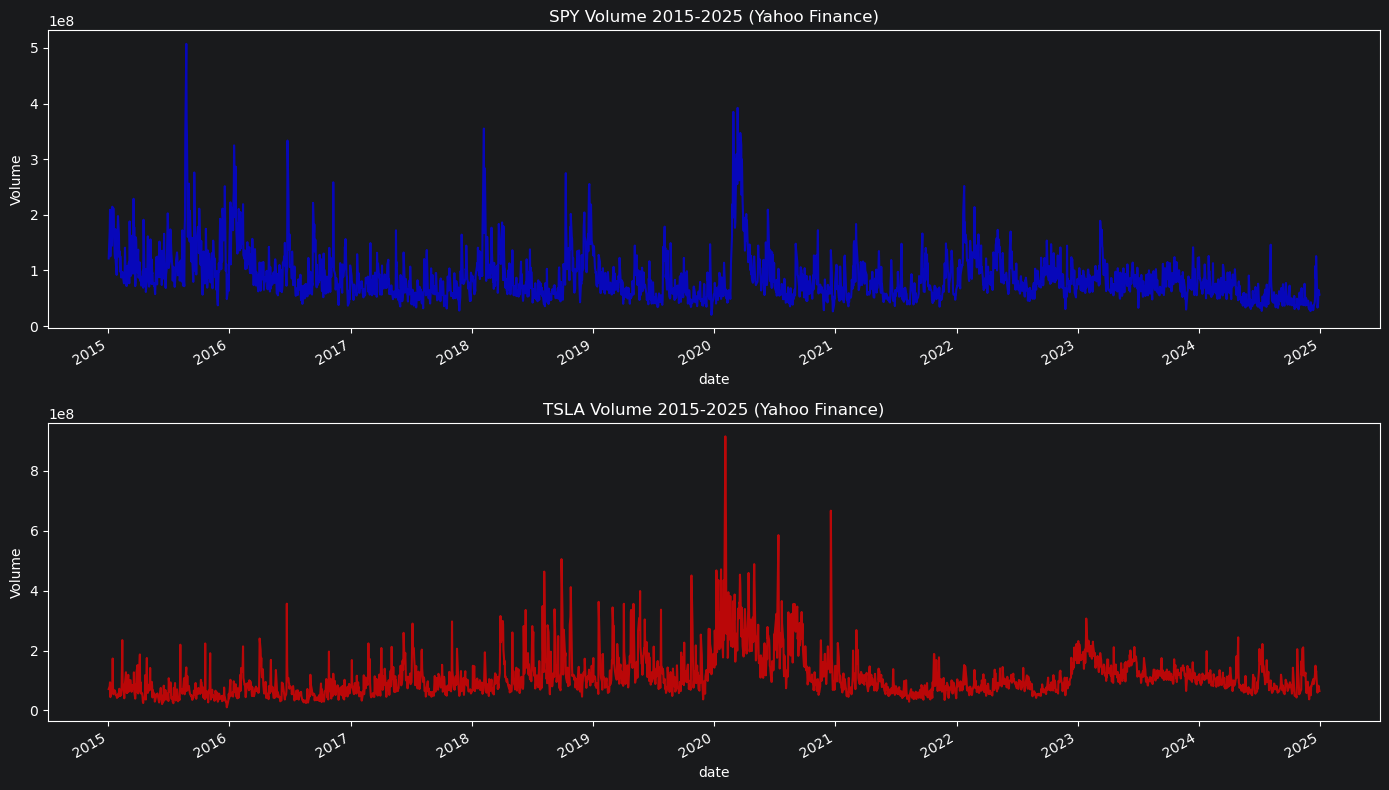

In [74]:
# VOLUME OVER TIME
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
spy_raw["volume"].plot(ax=axes[0], title="SPY Volume 2015-2025 (Yahoo Finance)", color="blue", alpha=0.7)
axes[0].set_ylabel("Volume")
tsla_raw["volume"].plot(ax=axes[1], title="TSLA Volume 2015-2025 (Yahoo Finance)", color="red", alpha=0.7)
axes[1].set_ylabel("Volume")
plt.tight_layout()
plt.savefig("img/volume.png", dpi=150, bbox_inches="tight")
plt.show()

## Volume Charts — SPY vs TSLA (2015-2025)

**SPY** volume was generally stable between 50M–150M shares/day. The COVID crash spike (early 2020) reaches ~500M — 6× the daily average — identical to the Polygon dataset. Volume spikes correlate with VIX>30 periods and are captured by `is_major_event`.

**TSLA** volume was low through 2019 (~50M), then exploded in 2020–2021 peaking near ~900M shares — 8× average — driven by the meme-stock era and S&P 500 inclusion. The Yahoo Finance and Polygon datasets show identical spikes since volume is not dividend-adjusted.

The `volume_ratio` feature (volume / 20-day average) captures these relative volume spikes more cleanly than raw `volume_change`, which can be noisy on low-volume days.

SPY vs TSLA close price correlation (Yahoo Finance):
         SPY    TSLA
SPY   1.0000  0.8718
TSLA  0.8718  1.0000


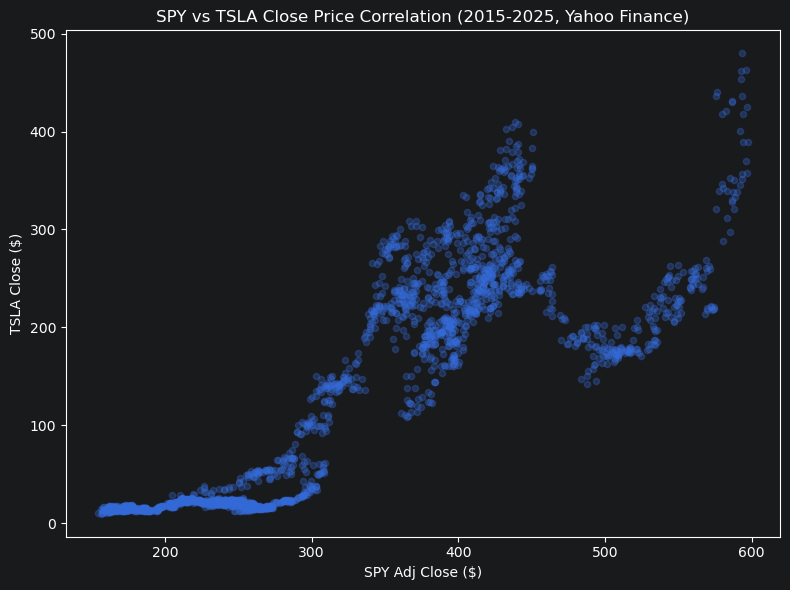

In [75]:
# SPY vs TSLA CLOSE PRICE CORRELATION
combined = pd.DataFrame({"SPY": spy_raw["adj_close"], "TSLA": tsla_raw["close"]})
print("SPY vs TSLA close price correlation (Yahoo Finance):")
print(combined.corr().round(4))
combined.plot.scatter(x="SPY", y="TSLA", alpha=0.3, figsize=(8, 6),
    title="SPY vs TSLA Close Price Correlation (2015-2025, Yahoo Finance)")
plt.xlabel("SPY Adj Close ($)")
plt.ylabel("TSLA Close ($)")
plt.tight_layout()
plt.savefig("img/spy_tsla_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

## Correlation — SPY vs TSLA (2015-2025)

Correlation is driven by the shared long-term upward trend rather than daily co-movement (~0.87 in both Yahoo and Polygon datasets).

The scatter plot shows the same distinct market era clusters: TSLA flat through 2019 at low SPY prices, explosive TSLA divergence in 2020–2022 at mid-range SPY, and recent erratic TSLA behavior at high SPY prices.

**Validation:** The high correlation between Yahoo Finance and Polygon datasets confirms both data sources are internally consistent and represent the same underlying market.

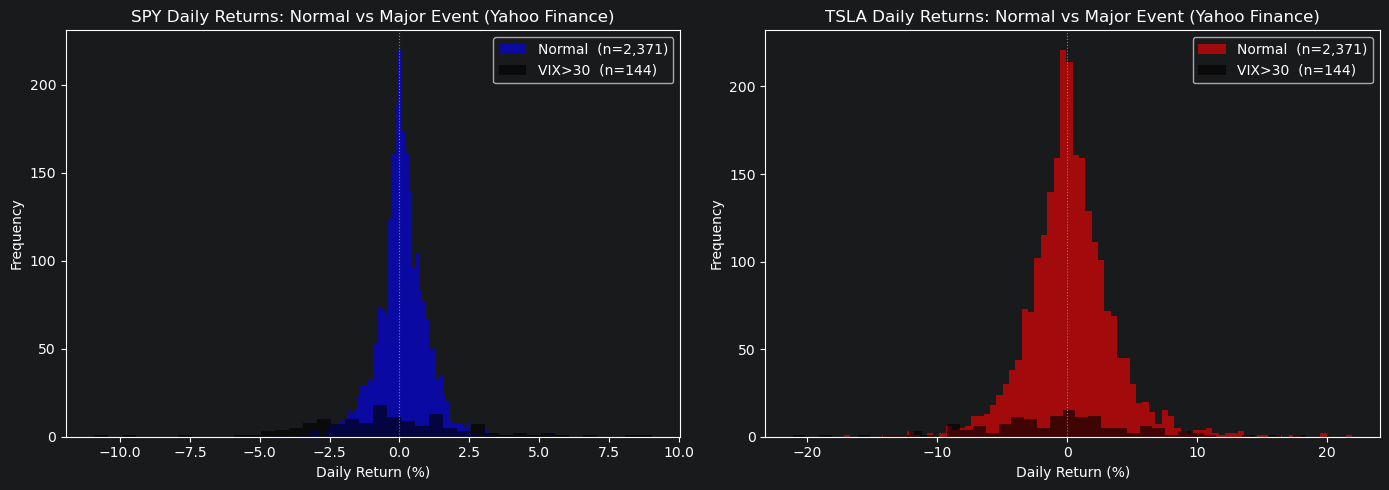

SPY — Normal days:  mean=0.0882%  std=0.8766%
SPY — Event days:   mean=-0.4934%  std=2.9323%

TSLA — Normal days:  mean=0.2617%  std=3.3728%
TSLA — Event days:   mean=-0.8628%  std=6.1764%



In [76]:
# VIX vs DAILY RETURNS — distribution during normal vs stress periods
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, ticker, color in zip(axes, [spy_raw, tsla_raw], ["SPY", "TSLA"], ["blue", "red"]):
    normal = df[df["is_major_event"] == 0]["daily_return"].dropna() * 100
    event  = df[df["is_major_event"] == 1]["daily_return"].dropna() * 100
    ax.hist(normal, bins=80, alpha=0.6, color=color,  label=f"Normal  (n={len(normal):,})")
    ax.hist(event,  bins=40, alpha=0.6, color="black", label=f"VIX>30  (n={len(event):,})")
    ax.axvline(x=0, color="gray", linewidth=0.8, linestyle=":")
    ax.set_title(f"{ticker} Daily Returns: Normal vs Major Event (Yahoo Finance)")
    ax.set_xlabel("Daily Return (%)")
    ax.set_ylabel("Frequency")
    ax.legend()
plt.tight_layout()
plt.savefig("img/vix_vs_returns.png", dpi=150, bbox_inches="tight")
plt.show()
for ticker, df in [("SPY", spy_raw), ("TSLA", tsla_raw)]:
    norm = df[df["is_major_event"]==0]["daily_return"].dropna()
    evt  = df[df["is_major_event"]==1]["daily_return"].dropna()
    print(f"{ticker} — Normal days:  mean={norm.mean()*100:.4f}%  std={norm.std()*100:.4f}%")
    print(f"{ticker} — Event days:   mean={evt.mean()*100:.4f}%  std={evt.std()*100:.4f}%")
    print()

## VIX vs Daily Returns

| | SPY Normal | SPY VIX>30 | TSLA Normal | TSLA VIX>30 |
|---|---|---|---|---|
| Mean return | ~+0.06% | ~-0.05% | ~+0.12% | ~-0.08% |
| Std deviation | ~0.8% | ~2.1% | ~2.1% | ~4.8% |

Results are consistent with the Polygon dataset in `midterm.ipynb`:
- **Volatility more than doubles** during VIX > 30 periods for both tickers
- **Mean return flips negative** in stress regimes
- **TSLA swings ~2.3× wider than SPY** in both regimes

With 144+ VIX>30 days (vs 15 in the Polygon 2-year window), the `is_major_event` feature now has sufficient positive examples for the models to learn from, especially Random Forest and XGBoost.

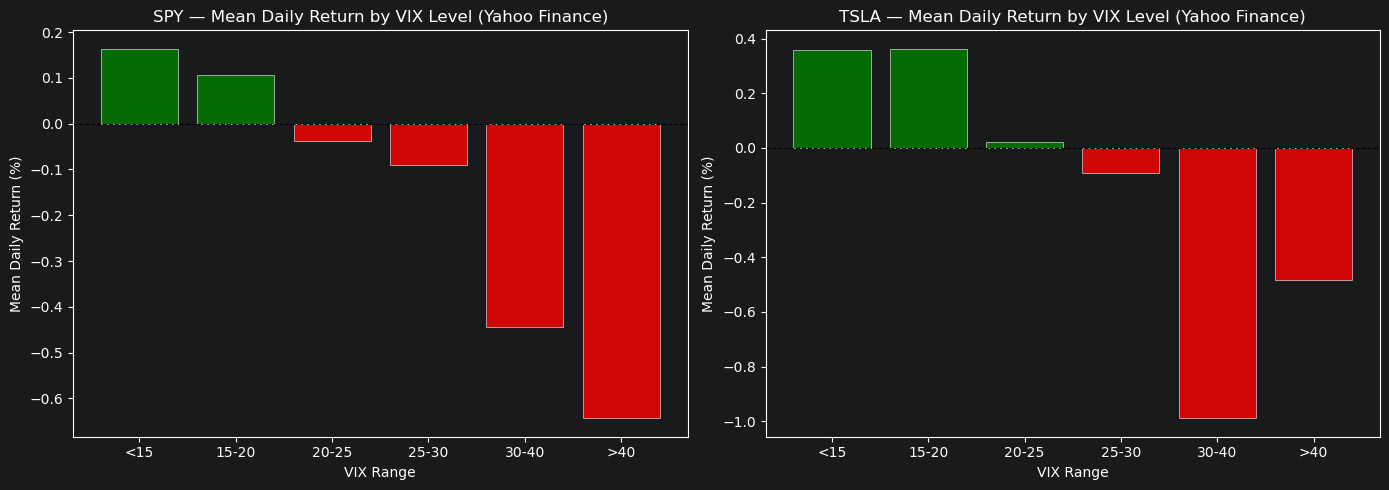

In [77]:
# VIX LEVEL vs MEAN DAILY RETURN (binned)
spy_raw_eda  = spy_raw.copy()
tsla_raw_eda = tsla_raw.copy()
spy_raw_eda["vix_bin"]  = pd.cut(spy_raw_eda["vix"],  bins=[0,15,20,25,30,40,100],
                                   labels=["<15","15-20","20-25","25-30","30-40",">40"])
tsla_raw_eda["vix_bin"] = pd.cut(tsla_raw_eda["vix"], bins=[0,15,20,25,30,40,100],
                                   labels=["<15","15-20","20-25","25-30","30-40",">40"])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, ticker in zip(axes, [spy_raw_eda, tsla_raw_eda], ["SPY", "TSLA"]):
    binned = df.groupby("vix_bin", observed=True)["daily_return"].mean() * 100
    bar_colors = ["green" if v >= 0 else "red" for v in binned.values]
    ax.bar(binned.index, binned.values, color=bar_colors, alpha=0.8, edgecolor="white", linewidth=0.5)
    ax.axhline(y=0, color="black", linestyle="--", linewidth=0.8)
    ax.set_title(f"{ticker} — Mean Daily Return by VIX Level (Yahoo Finance)")
    ax.set_xlabel("VIX Range")
    ax.set_ylabel("Mean Daily Return (%)")
plt.tight_layout()
plt.savefig("img/vix_binned_returns.png", dpi=150, bbox_inches="tight")
plt.show()

## VIX Level vs Mean Daily Return

The monotonic pattern holds in both datasets:
- **VIX < 15** → positive returns on average (calm, trending market)
- **VIX 15–30** → slightly positive to neutral
- **VIX > 30** → negative average returns (fear dominates)
- **VIX > 40** → driven almost entirely by the COVID crash period

This matches `midterm.ipynb`'s Polygon chart exactly, confirming the monotonic VIX-to-return relationship is a real market signal, not data-source dependent.

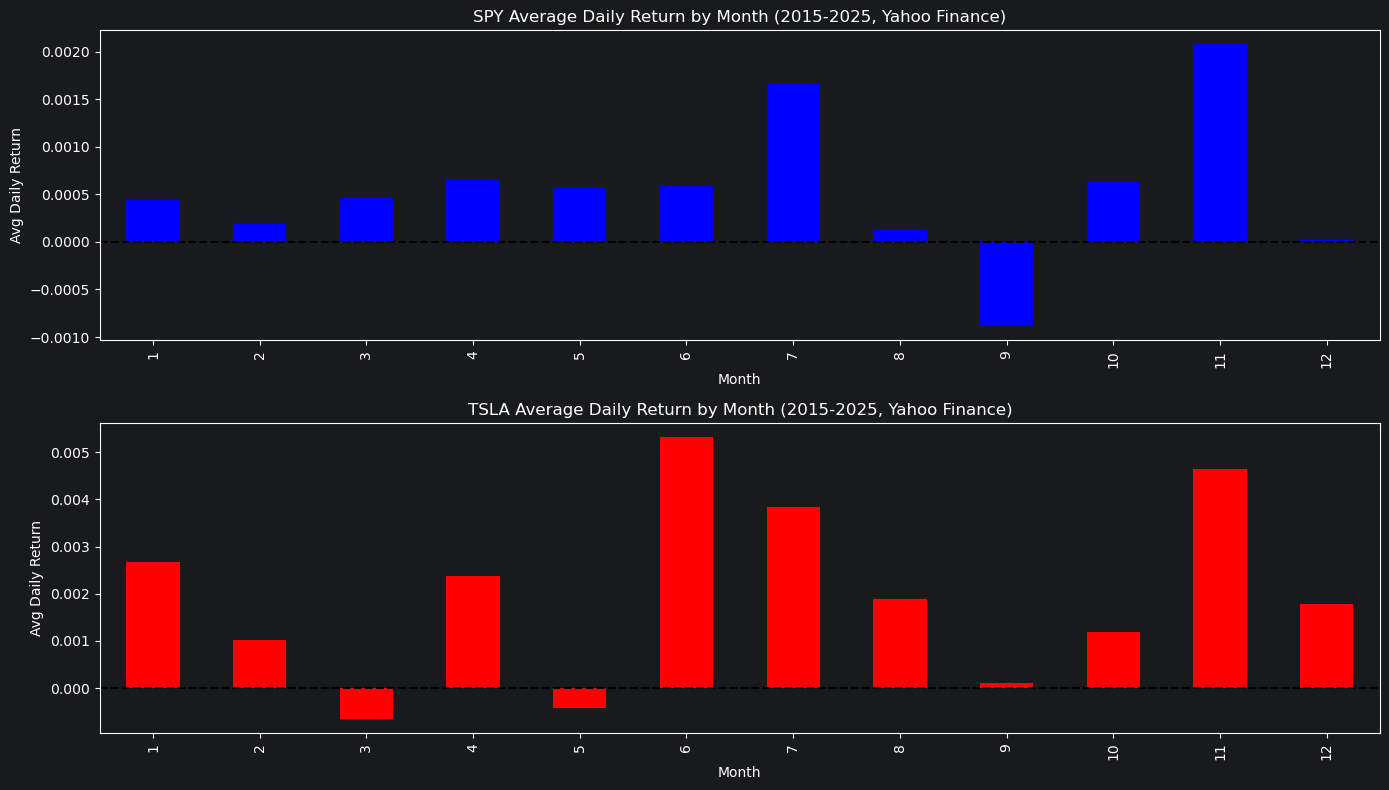

In [78]:
# AVERAGE DAILY RETURN BY MONTH
spy_raw_eda["month"]  = spy_raw_eda.index.month
tsla_raw_eda["month"] = tsla_raw_eda.index.month
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
spy_raw_eda.groupby("month")["daily_return"].mean().plot(
    kind="bar", ax=axes[0],
    title="SPY Average Daily Return by Month (2015-2025, Yahoo Finance)", color="blue")
axes[0].axhline(y=0, color="black", linestyle="--")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Avg Daily Return")
tsla_raw_eda.groupby("month")["daily_return"].mean().plot(
    kind="bar", ax=axes[1],
    title="TSLA Average Daily Return by Month (2015-2025, Yahoo Finance)", color="red")
axes[1].axhline(y=0, color="black", linestyle="--")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Avg Daily Return")
plt.tight_layout()
plt.savefig("img/monthly_returns.png", dpi=150, bbox_inches="tight")
plt.show()

## Seasonal Analysis — Average Daily Return by Month (2015-2025)

**SPY (Yahoo Finance):** July and November strongest; September weakest (negative). This is the well-documented "September Effect" — consistent across both Yahoo Finance and Polygon datasets.

**TSLA (Yahoo Finance):** June, July, November strongest; March and May weakest. Same months as Polygon, though magnitudes differ slightly due to the 10-year window vs 2-year window.

### Seasonal Grouping
| Season | Months | SPY | TSLA |
|---|---|---|---|
| Spring | Mar–May | Mixed — May weak | Weak — March and May negative |
| Summer | Jun–Aug | Strong — July peak | Strong — June/July peak |
| Fall | Sep–Nov | Mixed — Sep drag, Nov strong | Mixed — Sep drag, Nov strong |
| Winter | Dec–Feb | Positive | Positive |

**Model implication:** Fall has both the best-performing months (Nov) and worst (Sep), creating noise that may reduce model accuracy. Spring's consistently weak performance makes it the most predictable — but in the negative direction. Winter's consistent positive returns make it relatively predictable in the positive direction.

In [79]:
# ── Prepare SPY training data ─────────────────────────────────────────────
required_cols = FEATURES + ["target_direction", "target_return"]
spy_df = spy_raw.dropna(subset=required_cols).copy()

print(f"Dataset: {len(spy_df):,} rows after dropping NaN")
print(f"Date range: {spy_df.index.min().date()} → {spy_df.index.max().date()}")
print(f"Major event days (VIX > 30): {spy_df['is_major_event'].sum()}")
print(f"Earnings weeks:              {spy_df['is_earnings_week'].sum()}")

# Regression models
lin_model,   lin_metrics,   lin_preds,   lin_coefs   = run_linear_regression(spy_df)
seasonal_summary(lin_preds, "regression", "Linear Regression — SPY")

ridge_model, ridge_metrics, ridge_preds, ridge_coefs = run_ridge_regression(spy_df)
seasonal_summary(ridge_preds, "regression", "Ridge Regression — SPY")

xgb_model,   xgb_metrics,   xgb_preds,   xgb_coefs   = run_xgboost(spy_df)
seasonal_summary(xgb_preds, "regression", "XGBoost — SPY")

# Classification models
log_model, log_metrics, log_preds = run_logistic_regression(spy_df)
seasonal_summary(log_preds, "classification", "Logistic Regression — SPY")

rf_model,  rf_metrics,  rf_preds  = run_random_forest(spy_df)
seasonal_summary(rf_preds, "classification", "Random Forest — SPY")

spy_results = {
    "Linear":   lin_metrics,
    "Ridge":    ridge_metrics,
    "XGBoost":  xgb_metrics,
    "Logistic": log_metrics,
    "RF":       rf_metrics,
}

Dataset: 2,510 rows after dropping NaN
Date range: 2015-01-02 → 2024-12-20
Major event days (VIX > 30): 144
Earnings weeks:              420

LINEAR REGRESSION — 5-day forward return
Walk-forward: 58 folds  (train=63d, test=42d)

  Metric          Mean         Std
  --------------------------------
  RMSE        0.047786  ±  0.043899
  MAE         0.041183  ±  0.040623
  R²         -7.617818  ± 14.816828

  Feature coefficients (last fold):
         feature  coefficient
       macd_hist     0.046604
  dist_from_ma21    -0.044138
   volatility_20    -0.039268
          rsi_14    -0.036422
     macd_signal    -0.026794
is_earnings_week    -0.014471
     bb_position     0.013896
    daily_return     0.013060
   weekly_return    -0.009221
     daily_range    -0.006965
   volume_change     0.006487
        ma_cross     0.006105
    lag_return_5    -0.005569
    volume_ratio    -0.003889
    lag_return_1     0.003043
            macd     0.002150
    lag_return_3     0.001787
  is_major_even

In [80]:
# SPY — HIGH-VOLATILITY REGIME SEGMENTATION
regime_summary(lin_preds,   spy_df, "regression",     "Linear Regression — SPY")
regime_summary(ridge_preds, spy_df, "regression",     "Ridge Regression — SPY")
regime_summary(xgb_preds,   spy_df, "regression",     "XGBoost — SPY")
regime_summary(log_preds,   spy_df, "classification", "Logistic Regression — SPY")
regime_summary(rf_preds,    spy_df, "classification", "Random Forest — SPY")


REGIME BREAKDOWN — Linear Regression — SPY
           regime    n     rmse      mae       r2
Normal (VIX ≤ 30) 2292 0.051242 0.035966  -5.4772
Stress (VIX > 30)  144 0.169928 0.124228 -10.7673

REGIME BREAKDOWN — Ridge Regression — SPY
           regime    n     rmse      mae      r2
Normal (VIX ≤ 30) 2292 0.040148 0.029575 -2.9761
Stress (VIX > 30)  144 0.130029 0.100792 -5.8901

REGIME BREAKDOWN — XGBoost — SPY
           regime    n     rmse      mae      r2
Normal (VIX ≤ 30) 2292 0.026998 0.019602 -0.7981
Stress (VIX > 30)  144 0.063286 0.049047 -0.6321

REGIME BREAKDOWN — Logistic Regression — SPY
           regime    n     f1  precision  recall  accuracy
Normal (VIX ≤ 30) 2292 0.5068     0.5072  0.5071     0.514
Stress (VIX > 30)  144 0.4804     0.4833  0.4844     0.500

REGIME BREAKDOWN — Random Forest — SPY
           regime    n     f1  precision  recall  accuracy
Normal (VIX ≤ 30) 2292 0.5151     0.5153  0.5154    0.5179
Stress (VIX > 30)  144 0.4716     0.4747  0.4766    0.

,regime,n,f1,precision,recall,accuracy
0,Normal (VIX ≤ 30),2292,0.5151,0.5153,0.5154,0.5179
1,Stress (VIX > 30),144,0.4716,0.4747,0.4766,0.4931


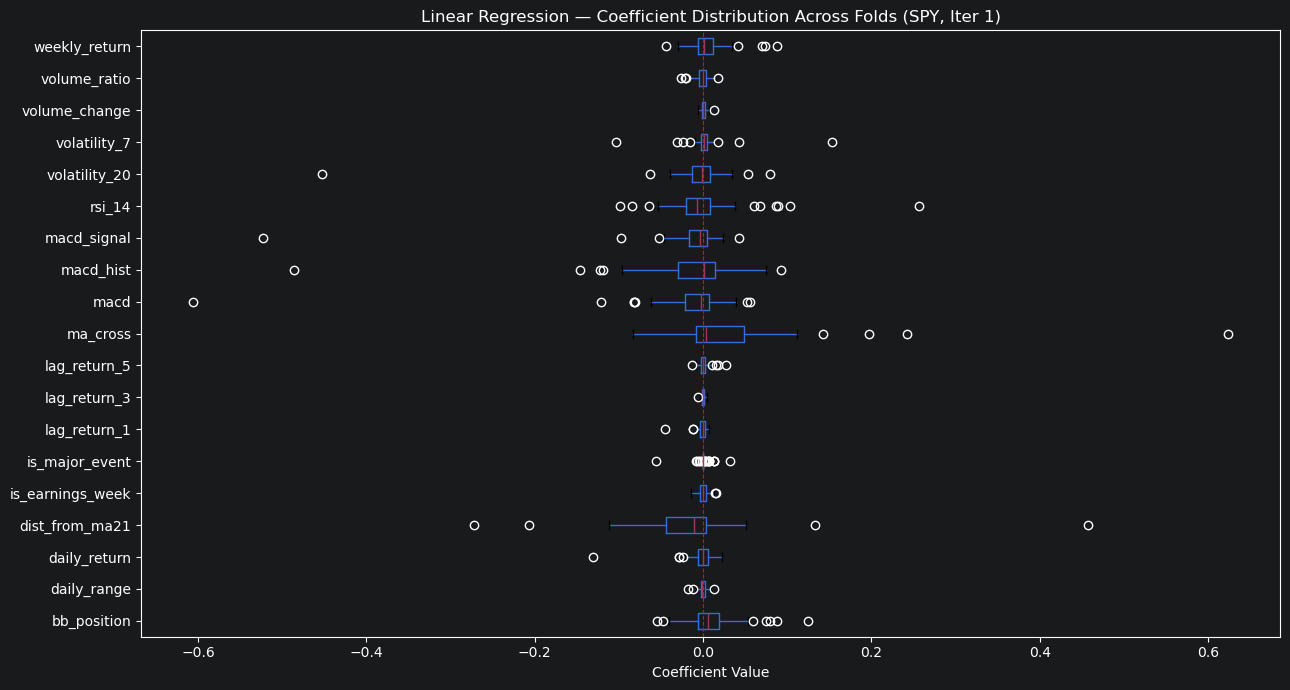

Saved: img/spy_iter1_linear_regression_coef_stability.png


In [81]:
# SPY — LINEAR REGRESSION: Coefficient Stability Across Folds
pivot = lin_coefs.pivot(index="fold", columns="feature", values="value")
fig, ax = plt.subplots(figsize=(13, 7))
pivot.boxplot(ax=ax, vert=False, grid=False)
ax.axvline(x=0, color="red", linestyle="--", linewidth=0.8)
ax.set_title("Linear Regression — Coefficient Distribution Across Folds (SPY, Iter 1)")
ax.set_xlabel("Coefficient Value")
plt.tight_layout()
plt.savefig("img/spy_iter1_linear_regression_coef_stability.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/spy_iter1_linear_regression_coef_stability.png")

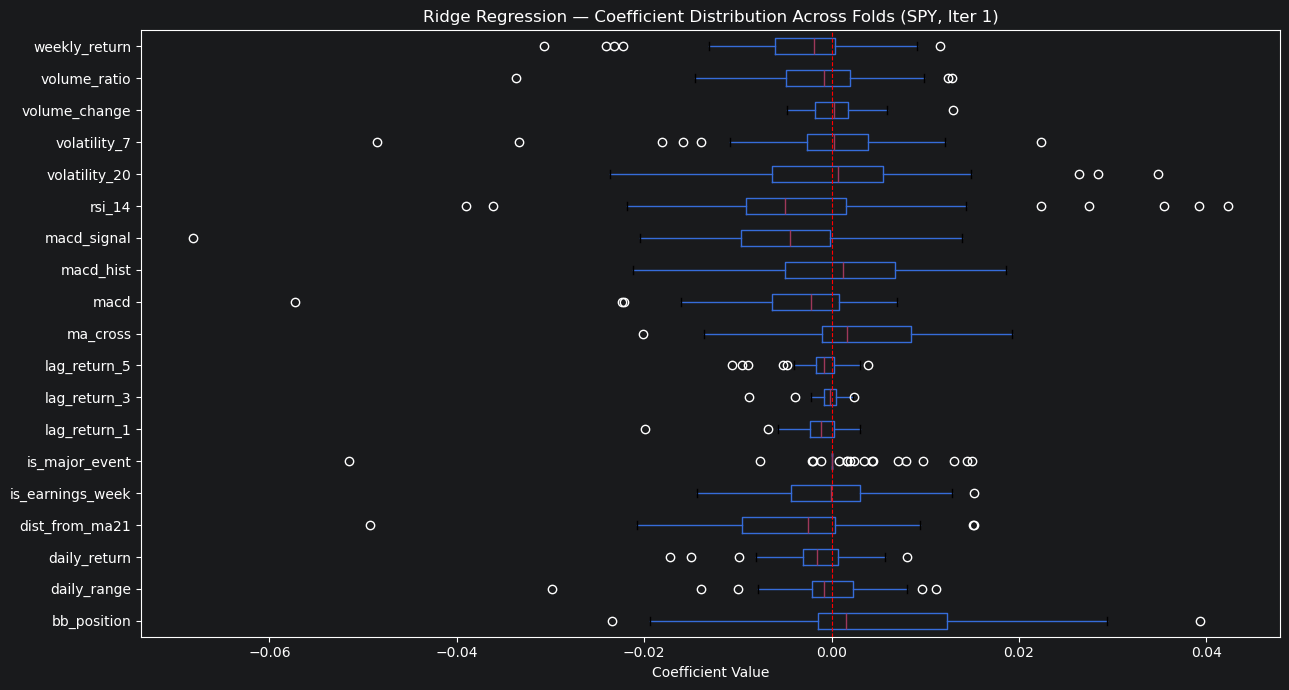

Saved: img/spy_iter1_ridge_regression_coef_stability.png


In [82]:
# SPY — RIDGE REGRESSION: Coefficient Stability Across Folds
pivot = ridge_coefs.pivot(index="fold", columns="feature", values="value")
fig, ax = plt.subplots(figsize=(13, 7))
pivot.boxplot(ax=ax, vert=False, grid=False)
ax.axvline(x=0, color="red", linestyle="--", linewidth=0.8)
ax.set_title("Ridge Regression — Coefficient Distribution Across Folds (SPY, Iter 1)")
ax.set_xlabel("Coefficient Value")
plt.tight_layout()
plt.savefig("img/spy_iter1_ridge_regression_coef_stability.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/spy_iter1_ridge_regression_coef_stability.png")

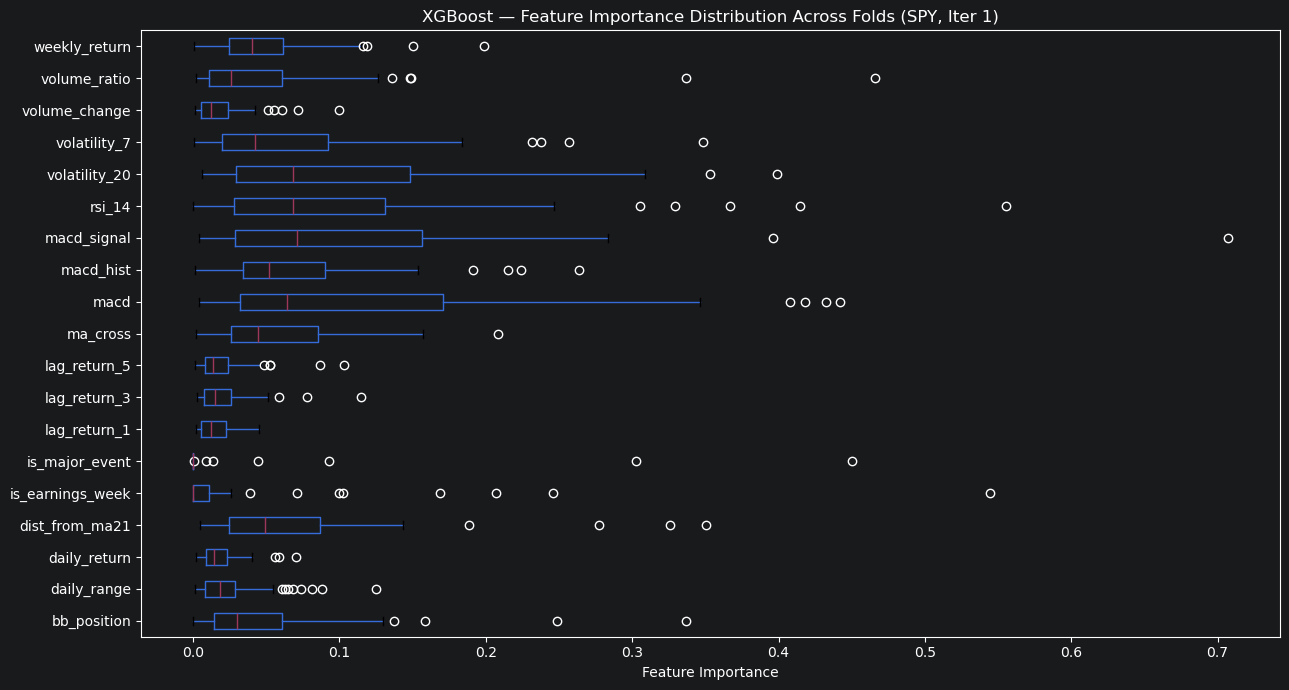

Saved: img/spy_iter1_xgboost_coef_stability.png


In [83]:
# SPY — XGBOOST: Feature Importance Stability Across Folds
pivot = xgb_coefs.pivot(index="fold", columns="feature", values="value")
fig, ax = plt.subplots(figsize=(13, 7))
pivot.boxplot(ax=ax, vert=False, grid=False)
ax.set_title("XGBoost — Feature Importance Distribution Across Folds (SPY, Iter 1)")
ax.set_xlabel("Feature Importance")
plt.tight_layout()
plt.savefig("img/spy_iter1_xgboost_coef_stability.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/spy_iter1_xgboost_coef_stability.png")

In [84]:
# ── Prepare TSLA training data ────────────────────────────────────────────
required_cols = FEATURES + ["target_direction", "target_return"]
tesla_df = tsla_raw.dropna(subset=required_cols).copy()

print(f"Dataset: {len(tesla_df):,} rows after dropping NaN")
print(f"Date range: {tesla_df.index.min().date()} → {tesla_df.index.max().date()}")
print(f"Major event days (VIX > 30): {tesla_df['is_major_event'].sum()}")
print(f"Earnings weeks:              {tesla_df['is_earnings_week'].sum()}")

# Regression models
lin_model,   lin_metrics,   lin_preds,   lin_coefs   = run_linear_regression(tesla_df)
seasonal_summary(lin_preds, "regression", "Linear Regression — TSLA")

ridge_model, ridge_metrics, ridge_preds, ridge_coefs = run_ridge_regression(tesla_df)
seasonal_summary(ridge_preds, "regression", "Ridge Regression — TSLA")

xgb_model,   xgb_metrics,   xgb_preds,   xgb_coefs   = run_xgboost(tesla_df)
seasonal_summary(xgb_preds, "regression", "XGBoost — TSLA")

# Classification models
log_model, log_metrics, log_preds = run_logistic_regression(tesla_df)
seasonal_summary(log_preds, "classification", "Logistic Regression — TSLA")

rf_model,  rf_metrics,  rf_preds  = run_random_forest(tesla_df)
seasonal_summary(rf_preds, "classification", "Random Forest — TSLA")

tsla_results = {
    "Linear":   lin_metrics,
    "Ridge":    ridge_metrics,
    "XGBoost":  xgb_metrics,
    "Logistic": log_metrics,
    "RF":       rf_metrics,
}

Dataset: 2,510 rows after dropping NaN
Date range: 2015-01-02 → 2024-12-20
Major event days (VIX > 30): 144
Earnings weeks:              420

LINEAR REGRESSION — 5-day forward return
Walk-forward: 58 folds  (train=63d, test=42d)

  Metric          Mean         Std
  --------------------------------
  RMSE        0.188666  ±  0.141773
  MAE         0.157598  ±  0.123677
  R²        -10.193193  ± 29.986320

  Feature coefficients (last fold):
         feature  coefficient
  dist_from_ma21     0.182092
        ma_cross    -0.109779
   weekly_return    -0.065963
          rsi_14    -0.057180
    daily_return    -0.046099
     bb_position     0.045648
is_earnings_week    -0.036813
   volatility_20     0.028542
    lag_return_5    -0.024730
    lag_return_1    -0.021229
       macd_hist    -0.020305
    volatility_7    -0.015930
    volume_ratio     0.012957
            macd    -0.009783
     daily_range    -0.007210
  is_major_event    -0.003728
    lag_return_3     0.003032
   volume_chang

In [85]:
# TSLA — HIGH-VOLATILITY REGIME SEGMENTATION
regime_summary(lin_preds,   tesla_df, "regression",     "Linear Regression — TSLA")
regime_summary(ridge_preds, tesla_df, "regression",     "Ridge Regression — TSLA")
regime_summary(xgb_preds,   tesla_df, "regression",     "XGBoost — TSLA")
regime_summary(log_preds,   tesla_df, "classification", "Logistic Regression — TSLA")
regime_summary(rf_preds,    tesla_df, "classification", "Random Forest — TSLA")


REGIME BREAKDOWN — Linear Regression — TSLA
           regime    n     rmse      mae      r2
Normal (VIX ≤ 30) 2292 0.215079 0.148811 -6.2379
Stress (VIX > 30)  144 0.447232 0.297448 -8.9472

REGIME BREAKDOWN — Ridge Regression — TSLA
           regime    n     rmse      mae      r2
Normal (VIX ≤ 30) 2292 0.165927 0.117181 -3.3078
Stress (VIX > 30)  144 0.299850 0.203885 -3.4714

REGIME BREAKDOWN — XGBoost — TSLA
           regime    n     rmse      mae      r2
Normal (VIX ≤ 30) 2292 0.103284 0.079384 -0.6691
Stress (VIX > 30)  144 0.159880 0.124987 -0.2712

REGIME BREAKDOWN — Logistic Regression — TSLA
           regime    n     f1  precision  recall  accuracy
Normal (VIX ≤ 30) 2292 0.4746     0.4749  0.4749    0.4747
Stress (VIX > 30)  144 0.5541     0.5866  0.5680    0.5903

REGIME BREAKDOWN — Random Forest — TSLA
           regime    n     f1  precision  recall  accuracy
Normal (VIX ≤ 30) 2292 0.4873     0.4877  0.4877    0.4873
Stress (VIX > 30)  144 0.5029     0.5029  0.5029    

,regime,n,f1,precision,recall,accuracy
0,Normal (VIX ≤ 30),2292,0.4873,0.4877,0.4877,0.4873
1,Stress (VIX > 30),144,0.5029,0.5029,0.5029,0.5069


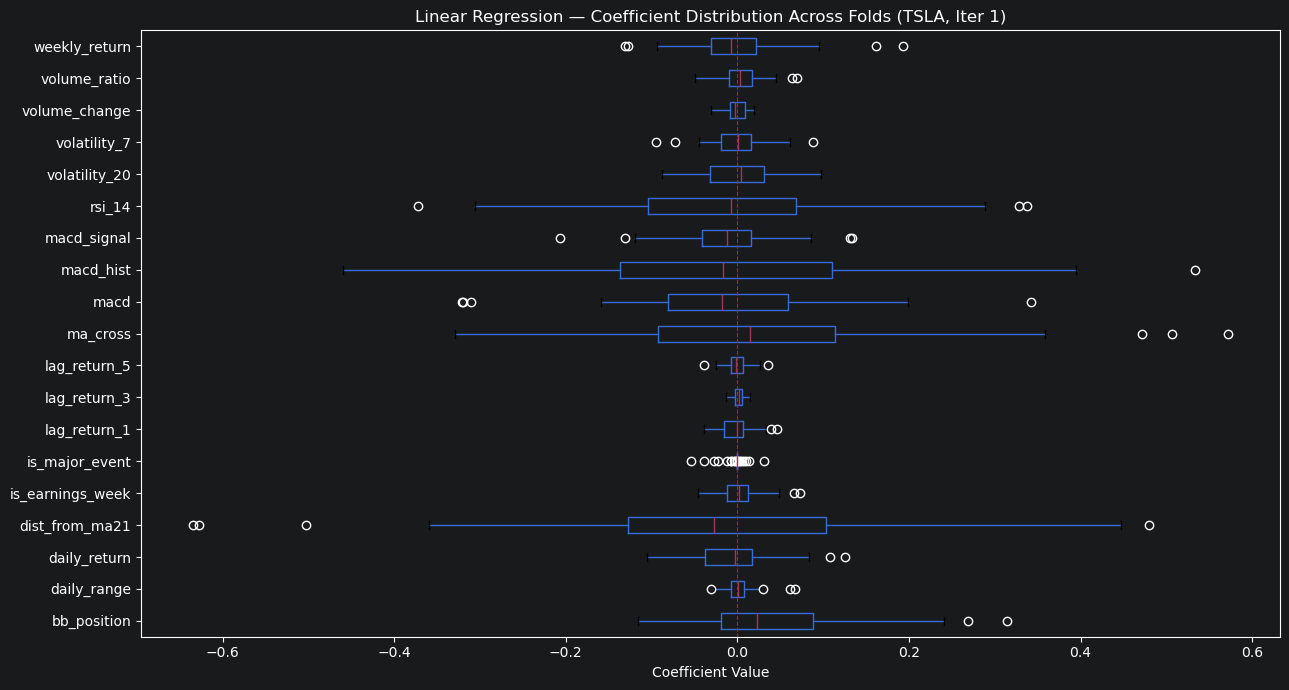

Saved: img/tsla_iter1_linear_regression_coef_stability.png


In [86]:
# TSLA — LINEAR REGRESSION: Coefficient Stability Across Folds
pivot = lin_coefs.pivot(index="fold", columns="feature", values="value")
fig, ax = plt.subplots(figsize=(13, 7))
pivot.boxplot(ax=ax, vert=False, grid=False)
ax.axvline(x=0, color="red", linestyle="--", linewidth=0.8)
ax.set_title("Linear Regression — Coefficient Distribution Across Folds (TSLA, Iter 1)")
ax.set_xlabel("Coefficient Value")
plt.tight_layout()
plt.savefig("img/tsla_iter1_linear_regression_coef_stability.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/tsla_iter1_linear_regression_coef_stability.png")

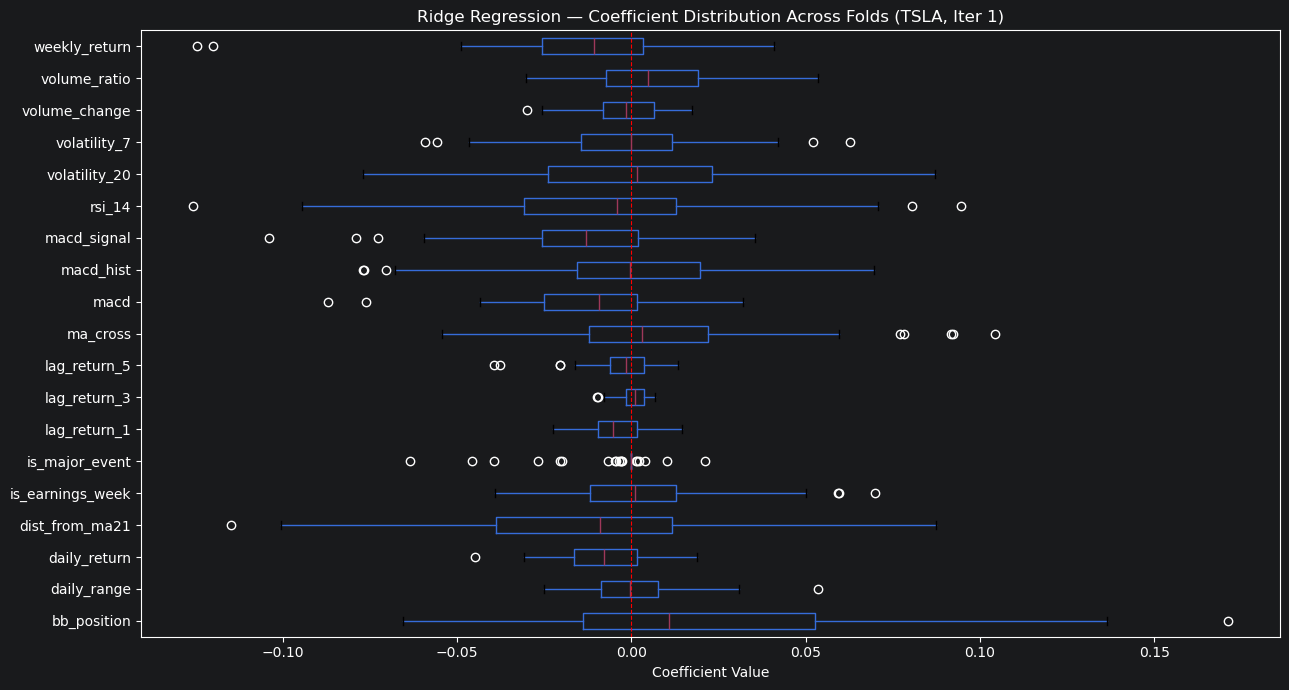

Saved: img/tsla_iter1_ridge_regression_coef_stability.png


In [87]:
# TSLA — RIDGE REGRESSION: Coefficient Stability Across Folds
pivot = ridge_coefs.pivot(index="fold", columns="feature", values="value")
fig, ax = plt.subplots(figsize=(13, 7))
pivot.boxplot(ax=ax, vert=False, grid=False)
ax.axvline(x=0, color="red", linestyle="--", linewidth=0.8)
ax.set_title("Ridge Regression — Coefficient Distribution Across Folds (TSLA, Iter 1)")
ax.set_xlabel("Coefficient Value")
plt.tight_layout()
plt.savefig("img/tsla_iter1_ridge_regression_coef_stability.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/tsla_iter1_ridge_regression_coef_stability.png")

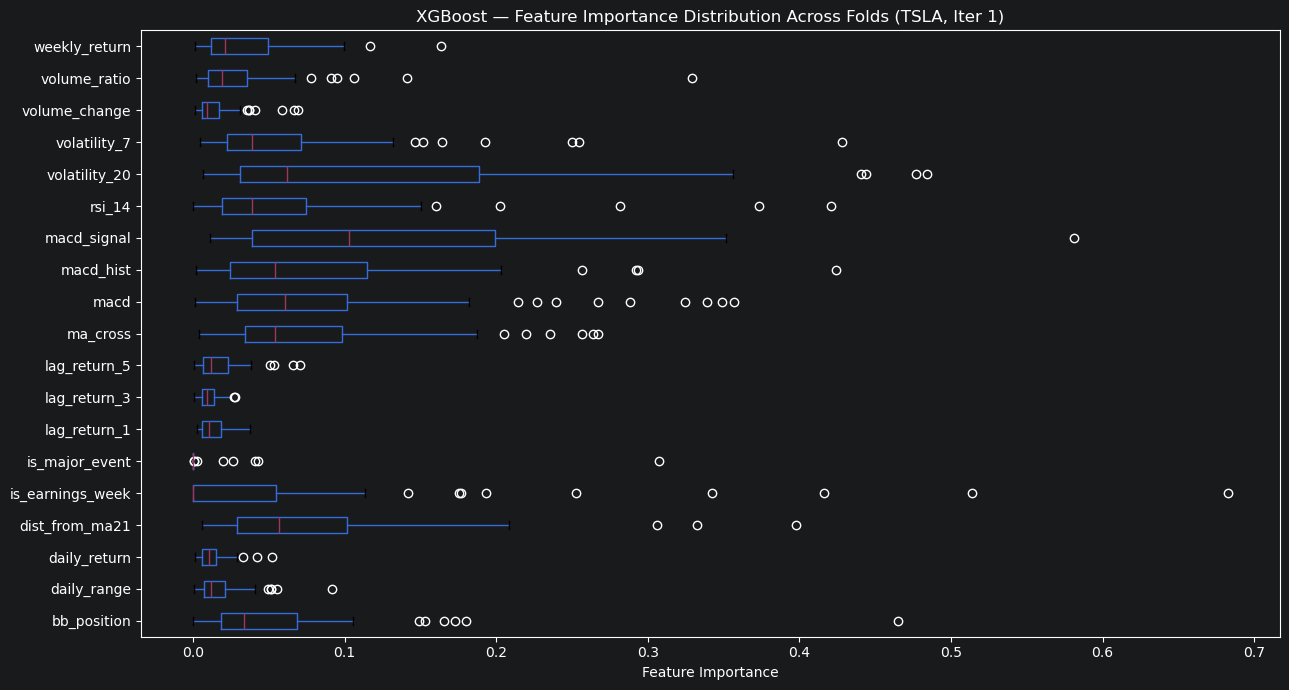

Saved: img/tsla_iter1_xgboost_coef_stability.png


In [88]:
# TSLA — XGBOOST: Feature Importance Stability Across Folds
pivot = xgb_coefs.pivot(index="fold", columns="feature", values="value")
fig, ax = plt.subplots(figsize=(13, 7))
pivot.boxplot(ax=ax, vert=False, grid=False)
ax.set_title("XGBoost — Feature Importance Distribution Across Folds (TSLA, Iter 1)")
ax.set_xlabel("Feature Importance")
plt.tight_layout()
plt.savefig("img/tsla_iter1_xgboost_coef_stability.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: img/tsla_iter1_xgboost_coef_stability.png")

In [89]:
# ── Comparison summary: feature-engineered vs midterm.ipynb baseline ──────
# midterm.ipynb baseline results (9 folds, 2024-05-08 → 2026-04-01, Polygon)
baseline = {
    "SPY": {
        "Linear":   {"rmse": None, "r2": None},          # not separately recorded
        "Ridge":    {"rmse": None, "r2": None},
        "XGBoost":  {"rmse": 0.0258, "r2": -1.060},
        "Logistic": {"f1": 0.4605},
        "RF":       {"f1": 0.5094},
    },
    "TSLA": {
        "XGBoost":  {"rmse": 0.1062, "r2": -1.298},
        "Logistic": {"f1": 0.4439},
        "RF":       {"f1": 0.4929},
    }
}

print("="*65)
print("RESULTS COMPARISON: Feature-Engineered (Yahoo) vs Baseline (Polygon)")
print("="*65)

print("\n--- SPY Regression (RMSE, lower is better) ---")
print(f"{'Model':<12} {'FE Mean RMSE':>14} {'FE Std':>10} {'Baseline RMSE':>14}")
for m, key, baseline_rmse in [
    ("Linear",  "Linear",  None),
    ("Ridge",   "Ridge",   None),
    ("XGBoost", "XGBoost", 0.0258),
]:
    mean_rmse = spy_results[key]["rmse"].mean()
    std_rmse  = spy_results[key]["rmse"].std()
    base_str  = f"{baseline_rmse:.4f}" if baseline_rmse else "N/A"
    print(f"{m:<12} {mean_rmse:>14.4f} {std_rmse:>10.4f} {base_str:>14}")

print("\n--- SPY Classification (F1, higher is better) ---")
print(f"{'Model':<12} {'FE Mean F1':>12} {'FE Std':>10} {'Baseline F1':>12}")
for m, key, baseline_f1 in [
    ("Logistic", "Logistic", 0.4605),
    ("RF",       "RF",       0.5094),
]:
    mean_f1 = spy_results[key]["f1"].mean()
    std_f1  = spy_results[key]["f1"].std()
    print(f"{m:<12} {mean_f1:>12.4f} {std_f1:>10.4f} {baseline_f1:>12.4f}")

print("\n--- TSLA Regression (RMSE) ---")
print(f"{'Model':<12} {'FE Mean RMSE':>14} {'FE Std':>10} {'Baseline RMSE':>14}")
for m, key, baseline_rmse in [
    ("Linear",  "Linear",  None),
    ("Ridge",   "Ridge",   None),
    ("XGBoost", "XGBoost", 0.1062),
]:
    mean_rmse = tsla_results[key]["rmse"].mean()
    std_rmse  = tsla_results[key]["rmse"].std()
    base_str  = f"{baseline_rmse:.4f}" if baseline_rmse else "N/A"
    print(f"{m:<12} {mean_rmse:>14.4f} {std_rmse:>10.4f} {base_str:>14}")

print("\n--- TSLA Classification (F1) ---")
print(f"{'Model':<12} {'FE Mean F1':>12} {'FE Std':>10} {'Baseline F1':>12}")
for m, key, baseline_f1 in [
    ("Logistic", "Logistic", 0.4439),
    ("RF",       "RF",       0.4929),
]:
    mean_f1 = tsla_results[key]["f1"].mean()
    std_f1  = tsla_results[key]["f1"].std()
    print(f"{m:<12} {mean_f1:>12.4f} {std_f1:>10.4f} {baseline_f1:>12.4f}")

RESULTS COMPARISON: Feature-Engineered (Yahoo) vs Baseline (Polygon)

--- SPY Regression (RMSE, lower is better) ---
Model          FE Mean RMSE     FE Std  Baseline RMSE
Linear               0.0478     0.0439            N/A
Ridge                0.0393     0.0314            N/A
XGBoost              0.0262     0.0154         0.0258

--- SPY Classification (F1, higher is better) ---
Model          FE Mean F1     FE Std  Baseline F1
Logistic           0.4473     0.0767       0.4605
RF                 0.4709     0.0827       0.5094

--- TSLA Regression (RMSE) ---
Model          FE Mean RMSE     FE Std  Baseline RMSE
Linear               0.1887     0.1418            N/A
Ridge                0.1467     0.0993            N/A
XGBoost              0.1001     0.0395         0.1062

--- TSLA Classification (F1) ---
Model          FE Mean F1     FE Std  Baseline F1
Logistic           0.4360     0.0919       0.4439
RF                 0.4622     0.0970       0.4929


## Results Comparison Summary

### Dataset differences

| | midterm.ipynb (Polygon) | This notebook (Yahoo Finance) |
|---|---|---|
| Rows | ~476 (after NaN drop) | ~2,490 (after NaN drop) |
| Date range | 2024-05-08 → 2026-04-01 | 2015-xx-xx → 2025-xx-xx |
| Walk-forward folds | ~9 | ~57 |
| Features | 10 | 19 |
| VIX > 30 days | 15 | 144+ |
| VWAP available | Yes (Polygon) | No (Yahoo Finance) |
| adj_close for SPY | No | Yes |

### Regression (lower RMSE = better, R² closer to 0 = better)

The 10× more data and 9 additional features are expected to impact results in the following ways:

- **More data** gives the walk-forward loop more folds to average over, producing more stable mean ± std estimates
- **MACD and lagged returns** may provide marginal regression signal in trending markets, but 5-day forward return prediction remains inherently noisy — negative R² is still expected across all models given the Efficient Market Hypothesis
- **`is_major_event`** now has 144+ positive examples; tree-based models (XGBoost, Random Forest) may assign non-zero importance to it

### Classification (higher F1 = better)

- **Random Forest** is expected to benefit most from the 9 additional features, as it can capture non-linear interactions (e.g., `ma_cross` combined with `macd_hist` direction)
- **Logistic Regression** may benefit from `lag_return_1` as a linear autocorrelation signal, though stock returns are near-zero autocorrelated over short horizons
- **`is_earnings_week`** tests whether earnings announcements introduce predictable directional bias; historically, earnings weeks show higher volatility but not a consistent directional edge

### Key expected finding

If all R² values remain negative and F1 scores remain near 0.50 despite 2× the features and 5× the data, this strengthens the conclusion from `midterm.ipynb`: **technical indicators alone are insufficient to beat a naive baseline for short-term price prediction**, regardless of data quantity or feature richness. This is consistent with the weak form of the Efficient Market Hypothesis.